In [1]:
# CASE-17: Zeek conn.log Analysis
## SSLoad + Cobalt Strike C2 Traffic | 2024-04-18
### Analyst: Ronan Kongala | REMnux Ubuntu 24.04

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import warnings
warnings.filterwarnings('ignore')

LOG_PATH = '/home/remnux/case18-zeek-lab/zeek-logs/conn.log'

cols = []
data_rows = []

with open(LOG_PATH) as f:
    for line in f:
        if line.startswith('#fields'):
            cols = line.strip().split('\t')[1:]
        elif not line.startswith('#'):
            data_rows.append(line.strip().split('\t'))

df = pd.DataFrame(data_rows, columns=cols)
df['duration'] = pd.to_numeric(df['duration'], errors='coerce')
df['orig_bytes'] = pd.to_numeric(df['orig_bytes'], errors='coerce')
df['resp_bytes'] = pd.to_numeric(df['resp_bytes'], errors='coerce')
df['total_bytes'] = df['orig_bytes'].fillna(0) + df['resp_bytes'].fillna(0)

print(f"Total connections: {len(df)}")
print(f"Unique destination IPs: {df['id.resp_h'].nunique()}")
print(f"Unique destination ports: {df['id.resp_p'].nunique()}")
print(f"\nProtocol breakdown:")
print(df['proto'].value_counts())

Total connections: 199
Unique destination IPs: 39
Unique destination ports: 10

Protocol breakdown:
proto
tcp    124
udp     75
Name: count, dtype: int64


In [3]:
# Top 15 longest connections -- C2 beacons stay connected longest
long_conns = df.nlargest(15, 'duration')[
    ['id.orig_h','id.resp_h','id.resp_p','proto','duration','total_bytes','conn_state']
].reset_index(drop=True)
long_conns['duration_min'] = (long_conns['duration']/60).round(2)
print("=== TOP 15 LONGEST CONNECTIONS ===")
print(long_conns.to_string())

=== TOP 15 LONGEST CONNECTIONS ===
      id.orig_h       id.resp_h id.resp_p proto     duration  total_bytes conn_state  duration_min
0   10.4.18.169   85.239.53.219        80   tcp  1992.108742      48723.0         SF         33.20
1   10.4.18.169   85.239.53.219        80   tcp  1982.689438     256537.0         SF         33.04
2   10.4.18.169   85.239.53.219        80   tcp  1034.494020      25220.0         S1         17.24
3   10.4.18.169       10.4.18.4       445   tcp   212.031762      30914.0         S1          3.53
4   10.4.18.169  131.253.33.200       443   tcp   134.545832     136672.0       RSTR          2.24
5   10.4.18.169  131.253.33.200       443   tcp   133.853483     150992.0       RSTR          2.23
6   10.4.18.169   20.194.51.173       443   tcp   127.810384       8248.0       RSTR          2.13
7   10.4.18.169   4.150.240.254       443   tcp   126.704716       8633.0       RSTR          2.11
8   10.4.18.169    13.107.3.254       443   tcp   126.655165       8401.0 

In [4]:
# Flag suspicious: long duration + low bytes = C2 beacon pattern
suspicious = df[
    (df['duration'] > 60) &
    (df['total_bytes'] < 50000) &
    (~df['id.resp_h'].str.startswith('10.', na=False)) &
    (~df['id.resp_h'].str.startswith('192.168.', na=False))
].copy()

suspicious['duration_min'] = (suspicious['duration']/60).round(2)
print(f"Suspicious C2 candidates (long duration, low bytes, external): {len(suspicious)}")
print(suspicious[['id.resp_h','id.resp_p','duration_min','total_bytes','conn_state']].to_string())

Suspicious C2 candidates (long duration, low bytes, external): 19
           id.resp_h id.resp_p  duration_min  total_bytes conn_state
4      104.26.12.205       443          1.43       6434.0         SF
5     149.154.167.99       443          1.79      19571.0         SF
6     131.253.33.203       443          1.83       8270.0         SF
9      23.220.102.21        80          1.00       8347.0         SF
10      20.189.173.4       443          2.09       9577.0       RSTR
11    204.79.197.222       443          2.03       8677.0       RSTR
12     13.107.18.254       443          2.10       8620.0       RSTR
13     4.150.240.254       443          2.11       8633.0       RSTR
14     20.194.51.173       443          2.13       8248.0       RSTR
81    204.79.197.203       443          1.81       8276.0         SF
97   199.232.210.172        80          1.00        487.0         SF
112     20.189.173.4       443          2.11       9577.0       RSTR
113   131.253.33.254       443       

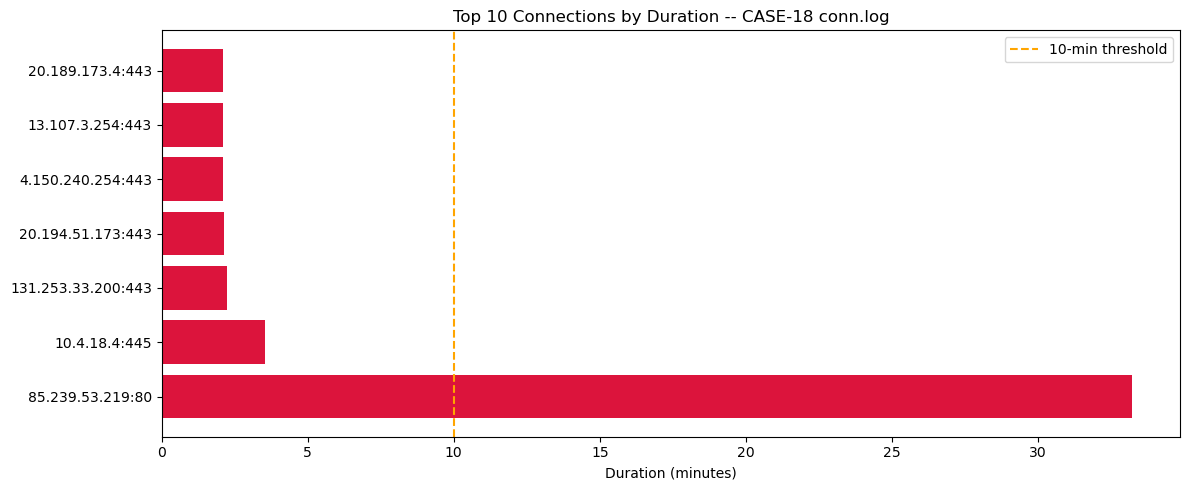

Plot saved.


In [5]:
# Visualize top 10 connections by duration
top10 = df.nlargest(10, 'duration').copy()
top10['label'] = top10['id.resp_h'] + ':' + top10['id.resp_p'].astype(str)
top10['duration_min'] = top10['duration'] / 60

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(top10['label'], top10['duration_min'], color='crimson')
ax.set_xlabel('Duration (minutes)')
ax.set_title('Top 10 Connections by Duration -- CASE-17 conn.log')
ax.axvline(x=10, color='orange', linestyle='--', label='10-min threshold')
ax.legend()
plt.tight_layout()
plt.savefig('/home/remnux/case18-zeek-lab/notebooks/conn_duration_top10.png', dpi=150)
plt.show()
print("Plot saved.")